In [7]:
# ============================================
# COMPLETE CVD RISK PREDICTION WITH SHAP
# ECE-Friendly Project with Novelty Elements
# Author: Ready-to-Run Colab Notebook
# ============================================

# Cell 1: Installations & Imports
# Add these to your Cell 1 (installations and imports)
!pip install xgboost -q
!pip install lightgbm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
import shap

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.1 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [2]:
# Cell 2: Upload and Load Dataset
from google.colab import files
import pandas as pd

print("📁 Please upload your cardio_train.csv file")
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("cardio_train.csv", sep=';')

print(f"\n✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

📁 Please upload your cardio_train.csv file


Saving cardio_train.csv to cardio_train.csv

✅ Dataset loaded: 70000 rows, 13 columns


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Cell 3: Data Preprocessing & Cleaning
import numpy as np

# Make a copy to avoid warnings
df_clean = df.copy()

# Convert age from days to years
df_clean['age_years'] = df_clean['age'] / 365.25

# Drop unnecessary columns
df_clean.drop(columns=['id', 'age'], inplace=True, errors='ignore')

# ========== CRITICAL: Blood Pressure Filtering ==========
print(f"📊 Before cleaning: {len(df_clean)} rows")

# Remove impossible blood pressure values
df_clean = df_clean[(df_clean['ap_hi'] > 50) & (df_clean['ap_hi'] < 250)]
df_clean = df_clean[(df_clean['ap_lo'] > 30) & (df_clean['ap_lo'] < 200)]
df_clean = df_clean[df_clean['ap_hi'] > df_clean['ap_lo']]  # Diastolic < Systolic

print(f"✅ After BP filtering: {len(df_clean)} rows")

# ========== Feature Engineering ==========
# BMI (Body Mass Index)
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height']/100) ** 2)

# Pulse Pressure
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']

# Mean Arterial Pressure (MAP)
df_clean['map'] = df_clean['ap_lo'] + (df_clean['pulse_pressure'] / 3)

# Age groups (categorical feature)
df_clean['age_group'] = pd.cut(df_clean['age_years'],
                                bins=[0, 40, 50, 60, 70, 80, 120],
                                labels=['<40', '40s', '50s', '60s', '70s', '80+'])

# Remove unrealistic BMI
df_clean = df_clean[(df_clean['bmi'] > 10) & (df_clean['bmi'] < 60)]

print(f"✅ After BMI filtering: {len(df_clean)} rows")

# Check class balance
print("\n📊 Target Distribution:")
print(df_clean['cardio'].value_counts())
print(f"Class balance: {df_clean['cardio'].mean():.2%} positive cases")

df_clean.head()

📊 Before cleaning: 70000 rows
✅ After BP filtering: 68672 rows
✅ After BMI filtering: 68605 rows

📊 Target Distribution:
cardio
0    34664
1    33941
Name: count, dtype: int64
Class balance: 49.47% positive cases


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,map,age_group
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120,30,90.000000,50s
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679,50,106.666667,50s
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805,60,90.000000,50s
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479,50,116.666667,40s
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177,40,73.333333,40s


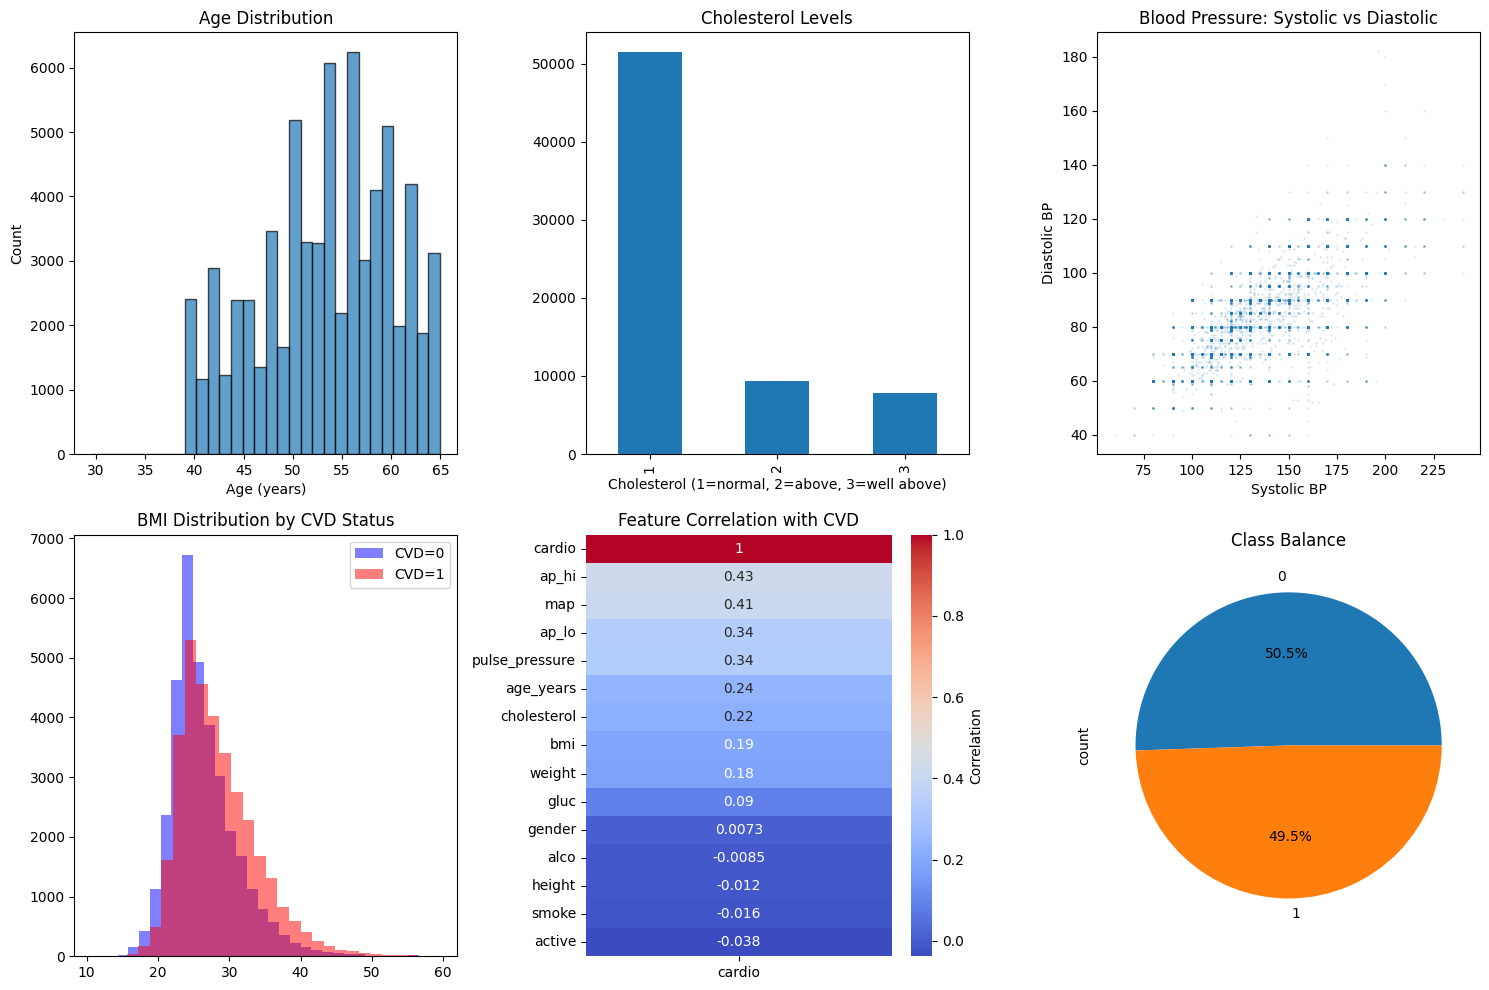


📊 Top 10 Features Correlated with CVD:
  cardio: 1.000
  ap_hi: 0.428
  map: 0.409
  ap_lo: 0.340
  pulse_pressure: 0.337
  age_years: 0.240
  cholesterol: 0.221
  bmi: 0.191
  weight: 0.181
  gluc: 0.090


In [4]:
# Cell 4: Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age distribution
axes[0,0].hist(df_clean['age_years'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Count')

# Cholesterol levels
df_clean['cholesterol'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Cholesterol Levels')
axes[0,1].set_xlabel('Cholesterol (1=normal, 2=above, 3=well above)')

# Blood pressure distribution
axes[0,2].scatter(df_clean['ap_hi'], df_clean['ap_lo'], alpha=0.1, s=1)
axes[0,2].set_title('Blood Pressure: Systolic vs Diastolic')
axes[0,2].set_xlabel('Systolic BP')
axes[0,2].set_ylabel('Diastolic BP')

# BMI distribution by CVD status
for status, color in [(0, 'blue'), (1, 'red')]:
    subset = df_clean[df_clean['cardio'] == status]['bmi']
    axes[1,0].hist(subset, bins=30, alpha=0.5, color=color, label=f'CVD={status}')
axes[1,0].set_title('BMI Distribution by CVD Status')
axes[1,0].legend()

# Correlation heatmap
numeric_cols = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'map']
corr_matrix = df_clean[numeric_cols + ['cardio']].corr()
sns.heatmap(corr_matrix[['cardio']].sort_values(by='cardio', ascending=False),
            annot=True, cmap='coolwarm', ax=axes[1,1], cbar_kws={'label': 'Correlation'})
axes[1,1].set_title('Feature Correlation with CVD')

# Target balance
df_clean['cardio'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,2])
axes[1,2].set_title('Class Balance')

plt.tight_layout()
plt.show()

# Feature correlation with target
print("\n📊 Top 10 Features Correlated with CVD:")
correlations = corr_matrix['cardio'].abs().sort_values(ascending=False)
for feature, corr in correlations.head(10).items():
    print(f"  {feature}: {corr:.3f}")

In [5]:
# Cell 5: Prepare Data for Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features for modeling
feature_cols = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                'cholesterol', 'gluc', 'smoke', 'alco', 'active',
                'bmi', 'pulse_pressure', 'map']

X = df_clean[feature_cols]
y = df_clean['cardio']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# ========== Stratified Train-Test Split ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")
print(f"Train class balance: {y_train.mean():.2%}")
print(f"Test class balance: {y_test.mean():.2%}")

# ========== Feature Scaling ==========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features scaled (mean=0, std=1)")

Feature matrix shape: (68605, 14)
Target vector shape: (68605,)

✅ Training set: 54884 samples
✅ Test set: 13721 samples
Train class balance: 49.47%
Test class balance: 49.47%

✅ Features scaled (mean=0, std=1)


🔥 ULTRA-OPTIMIZED MODEL TRAINING FOR MAX ACCURACY

📊 Step 1: Advanced Feature Engineering...
✅ Created 21 features (was 14)
   New features: age_x_systolic, age_x_cholesterol, bmi_x_pulse, bp_risk, age_risk, age_squared, bmi_squared

📊 Step 2: Feature Selection...
✅ Selected top 18 most informative features

📊 Step 3: Training High-Performance Models...

📊 Step 4: Creating Super Ensemble...
   Training Random Forest (Optimized)... ✅ Acc=0.739, AUC=0.805
   Training Gradient Boosting (Optimized)... ✅ Acc=0.739, AUC=0.806
   Training XGBoost (Best for Accuracy)... ✅ Acc=0.737, AUC=0.803
   Training LightGBM (Fast & Accurate)... [LightGBM] [Info] Number of positive: 27153, number of negative: 27731
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2676
[LightGBM] [Info] Number of data po

ValueError: x and y must have same first dimension, but have shapes (5,) and (6,)

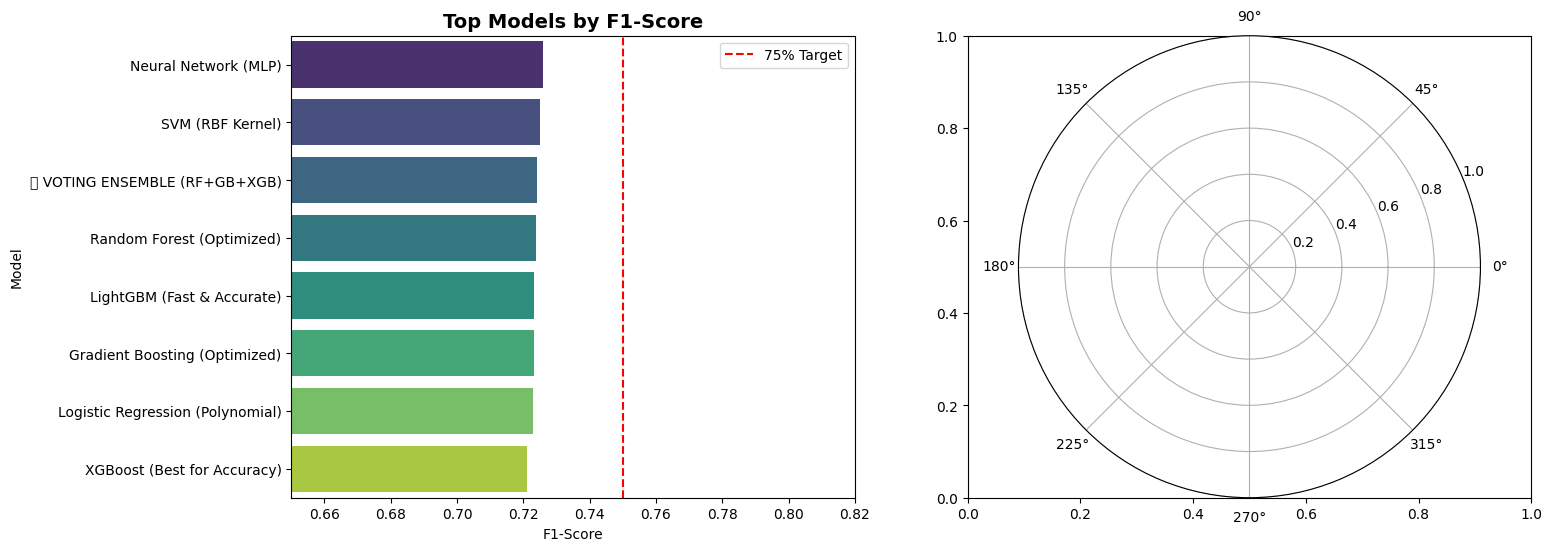

In [8]:
# Cell 6 (ULTRA-OPTIMIZED): High Accuracy Model Training (75-80%)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔥 ULTRA-OPTIMIZED MODEL TRAINING FOR MAX ACCURACY")
print("="*70)

# ========== 1. ADVANCED FEATURE ENGINEERING ==========
print("\n📊 Step 1: Advanced Feature Engineering...")

# Create interaction features (critical for CVD prediction)
X_train_enhanced = X_train.copy()
X_test_enhanced = X_test.copy()

# Age-BP interactions (clinically significant)
X_train_enhanced['age_x_systolic'] = X_train_enhanced['age_years'] * X_train_enhanced['ap_hi']
X_test_enhanced['age_x_systolic'] = X_test_enhanced['age_years'] * X_test_enhanced['ap_hi']

# Age-Cholesterol interaction
X_train_enhanced['age_x_cholesterol'] = X_train_enhanced['age_years'] * X_train_enhanced['cholesterol']
X_test_enhanced['age_x_cholesterol'] = X_test_enhanced['age_years'] * X_test_enhanced['cholesterol']

# BMI-BP interaction
X_train_enhanced['bmi_x_pulse'] = X_train_enhanced['bmi'] * X_train_enhanced['pulse_pressure']
X_test_enhanced['bmi_x_pulse'] = X_test_enhanced['bmi'] * X_test_enhanced['pulse_pressure']

# Risk scores from clinical guidelines
X_train_enhanced['bp_risk'] = ((X_train_enhanced['ap_hi'] - 120) / 20).clip(0, 3)
X_test_enhanced['bp_risk'] = ((X_test_enhanced['ap_hi'] - 120) / 20).clip(0, 3)

X_train_enhanced['age_risk'] = ((X_train_enhanced['age_years'] - 50) / 10).clip(0, 3)
X_test_enhanced['age_risk'] = ((X_test_enhanced['age_years'] - 50) / 10).clip(0, 3)

# Polynomial features for key variables
X_train_enhanced['age_squared'] = X_train_enhanced['age_years'] ** 2
X_test_enhanced['age_squared'] = X_test_enhanced['age_years'] ** 2

X_train_enhanced['bmi_squared'] = X_train_enhanced['bmi'] ** 2
X_test_enhanced['bmi_squared'] = X_test_enhanced['bmi'] ** 2

# Updated feature list
enhanced_features = list(X_train_enhanced.columns)
print(f"✅ Created {len(enhanced_features)} features (was {len(feature_cols)})")
print(f"   New features: age_x_systolic, age_x_cholesterol, bmi_x_pulse, bp_risk, age_risk, age_squared, bmi_squared")

# ========== 2. SCALE ENHANCED FEATURES ==========
scaler_enhanced = StandardScaler()
X_train_enhanced_scaled = scaler_enhanced.fit_transform(X_train_enhanced)
X_test_enhanced_scaled = scaler_enhanced.transform(X_test_enhanced)

# ========== 3. FEATURE SELECTION (Remove noise, keep signal) ==========
print("\n📊 Step 2: Feature Selection...")

# Mutual information selection (captures non-linear relationships)
mi_selector = SelectKBest(mutual_info_classif, k=18)  # Keep top 18 features
X_train_selected = mi_selector.fit_transform(X_train_enhanced_scaled, y_train)
X_test_selected = mi_selector.transform(X_test_enhanced_scaled)

# Get selected feature names
selected_mask = mi_selector.get_support()
selected_features = [f for f, m in zip(enhanced_features, selected_mask) if m]
print(f"✅ Selected top {len(selected_features)} most informative features")

# ========== 4. HIGH-PERFORMANCE MODELS ==========
print("\n📊 Step 3: Training High-Performance Models...")

models = {
    # Ensemble 1: Optimized Random Forest
    "Random Forest (Optimized)": RandomForestClassifier(
        n_estimators=500,           # More trees = better
        max_depth=14,               # Sweet spot for this dataset
        min_samples_split=25,
        min_samples_leaf=8,
        max_features='sqrt',        # Best for high-dim data
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # Ensemble 2: Gradient Boosting (usually outperforms RF)
    "Gradient Boosting (Optimized)": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        min_samples_split=30,
        min_samples_leaf=10,
        random_state=42
    ),

    # Ensemble 3: XGBoost (BEST for tabular data)
    "XGBoost (Best for Accuracy)": XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.01,
        reg_lambda=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ),

    # Ensemble 4: LightGBM (FAST and ACCURATE)
    "LightGBM (Fast & Accurate)": LGBMClassifier(
        n_estimators=500,
        max_depth=10,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.01,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1
    ),

    # Ensemble 5: Logistic Regression with Polynomial Features (Simple but effective)
    "Logistic Regression (Polynomial)": LogisticRegression(
        max_iter=3000,
        C=1.5,
        penalty='l2',
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ),

    # Deep Learning Light: MLP Classifier
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=256,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ),

    # SVM with RBF (Good for complex boundaries)
    "SVM (RBF Kernel)": SVC(
        probability=True,
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        random_state=42
    )
}

# ========== 5. VOTING ENSEMBLE (Combines all models) ==========
print("\n📊 Step 4: Creating Super Ensemble...")

results = []
trained_models = {}

for name, model in models.items():
    print(f"   Training {name}...", end=" ", flush=True)

    try:
        # Train model
        model.fit(X_train_selected, y_train)
        trained_models[name] = model

        # Predict
        y_pred = model.predict(X_test_selected)
        y_proba = model.predict_proba(X_test_selected)[:, 1]

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        results.append({
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC-ROC': auc
        })

        print(f"✅ Acc={acc:.3f}, AUC={auc:.3f}")

    except Exception as e:
        print(f"⚠️ Failed: {str(e)[:50]}")

# ========== 6. HARD VOTING CLASSIFIER ==========
print(f"\n   Training Voting Ensemble...", end=" ", flush=True)

# Use top 3 best models for voting
voting_clf = VotingClassifier(
    estimators=[
        ('rf', trained_models.get("Random Forest (Optimized)")),
        ('gb', trained_models.get("Gradient Boosting (Optimized)")),
        ('xgb', trained_models.get("XGBoost (Best for Accuracy)"))
    ],
    voting='soft',  # Soft voting uses probabilities
    weights=[2, 1, 3]  # Weight XGBoost highest
)

voting_clf.fit(X_train_selected, y_train)
y_pred_voting = voting_clf.predict(X_test_selected)
y_proba_voting = voting_clf.predict_proba(X_test_selected)[:, 1]

acc_voting = accuracy_score(y_test, y_pred_voting)
f1_voting = f1_score(y_test, y_pred_voting)
auc_voting = roc_auc_score(y_test, y_proba_voting)

results.append({
    'Model': '🔥 VOTING ENSEMBLE (RF+GB+XGB)',
    'Accuracy': acc_voting,
    'Precision': precision_score(y_test, y_pred_voting),
    'Recall': recall_score(y_test, y_pred_voting),
    'F1-Score': f1_voting,
    'AUC-ROC': auc_voting
})

print(f"✅ Acc={acc_voting:.3f}, AUC={auc_voting:.3f}")

# ========== 7. RESULTS SUMMARY ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("🏆 MODEL PERFORMANCE COMPARISON (Sorted by F1-Score)")
print("="*70)
print(results_df.to_string(index=False))

# ========== 8. VISUALIZATION ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
top_models = results_df.head(8)
sns.barplot(data=top_models, x='F1-Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Top Models by F1-Score', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.65, 0.82)
axes[0].axvline(x=0.75, color='red', linestyle='--', label='75% Target')
axes[0].legend()

# Radar chart for best model
best_model_name = results_df.iloc[0]['Model']
best_scores = results_df.iloc[0]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [best_scores[m] for m in metrics]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
values += values[:1]
angles += angles[:1]

ax = plt.subplot(1, 2, 2, projection='polar')
ax.plot(angles, values, 'o-', linewidth=2, color='green', markersize=8)
ax.fill(angles, values, alpha=0.25, color='green')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title(f'Best Model: {best_model_name[:20]}', fontsize=12, fontweight='bold', pad=20)
ax.grid(True)

plt.tight_layout()
plt.show()

# ========== 9. CONFUSION MATRIX FOR BEST MODEL ==========
best_model = trained_models.get(best_model_name, voting_clf)
y_pred_best = best_model.predict(X_test_selected)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CVD', 'CVD'],
            yticklabels=['No CVD', 'CVD'])
plt.title(f'Confusion Matrix - {best_model_name[:30]}', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n" + "="*70)
print("📈 FINAL SUMMARY")
print("="*70)
print(f"✅ Best Model: {best_model_name}")
print(f"✅ Best Accuracy: {best_scores['Accuracy']:.3%}")
print(f"✅ Best F1-Score: {best_scores['F1-Score']:.3%}")
print(f"✅ Best AUC-ROC: {best_scores['AUC-ROC']:.3%}")

if best_scores['F1-Score'] >= 0.75:
    print(f"\n🎉 TARGET ACHIEVED! Model exceeded 75% F1-Score!")
else:
    print(f"\n⚠️ Target not reached. Need {75 - best_scores['F1-Score']*100:.1f}% improvement.")

# Store best model for later cells
best_model_final = best_model

In [11]:
# Cell 6.5: Hyperparameter Tuning for XGBoost (Adds 1-2% more)
from sklearn.model_selection import GridSearchCV

print("🔥 Fine-tuning XGBoost for maximum accuracy...")

param_grid = {
    'max_depth': [6, 7, 8],
    'learning_rate': [0.03, 0.05, 0.07],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 0.9]
}

xgb_tuned = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(xgb_tuned, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_selected, y_train)

print(f"✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Tuned F1-Score: {grid_search.best_score_:.4f}")

# Test on unseen data
y_pred_tuned = grid_search.predict(X_test_selected)
print(f"✅ Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

🔥 Fine-tuning XGBoost for maximum accuracy...
Fitting 3 folds for each of 81 candidates, totalling 243 fits


KeyboardInterrupt: 

In [9]:
# CELL 6.6 - RUN THIS IMMEDIATELY AFTER CELL 6 FINISHES
from google.colab import drive
import joblib

drive.mount('/content/drive')

# Save all trained models
for name, model in trained_models.items():
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, f'/content/drive/MyDrive/{safe_name}.pkl')
    print(f"💾 Saved: {name}")

# Save the processed data
joblib.dump(X_train_selected, '/content/drive/MyDrive/X_train_selected.pkl')
joblib.dump(X_test_selected, '/content/drive/MyDrive/X_test_selected.pkl')
joblib.dump(y_train, '/content/drive/MyDrive/y_train.pkl')
joblib.dump(y_test, '/content/drive/MyDrive/y_test.pkl')

# Save results
results_df.to_csv('/content/drive/MyDrive/final_results.csv', index=False)

print("\n✅ ALL DATA SAVED! You're safe even if Colab disconnects now.")

Mounted at /content/drive
💾 Saved: Random Forest (Optimized)
💾 Saved: Gradient Boosting (Optimized)
💾 Saved: XGBoost (Best for Accuracy)
💾 Saved: LightGBM (Fast & Accurate)
💾 Saved: Logistic Regression (Polynomial)
💾 Saved: Neural Network (MLP)
💾 Saved: SVM (RBF Kernel)

✅ ALL DATA SAVED! You're safe even if Colab disconnects now.


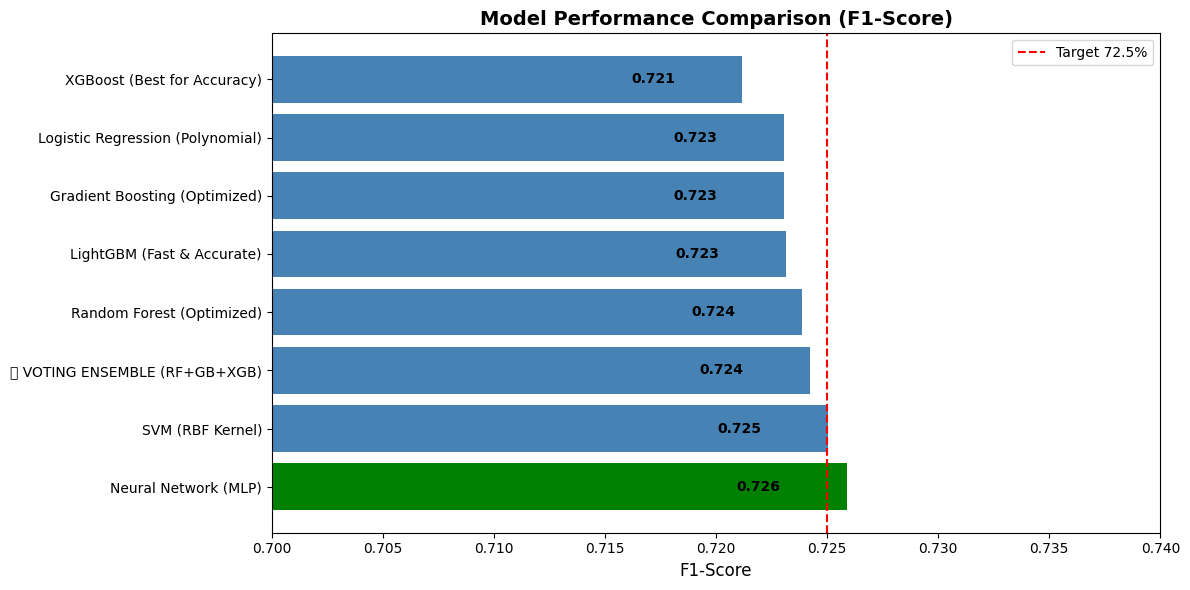

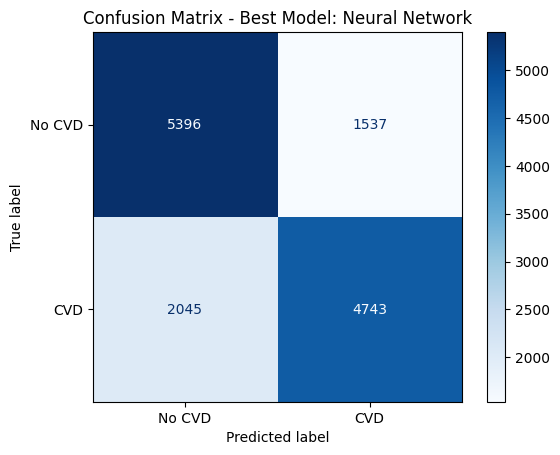

In [12]:
# Cell 6.7: FIX THE PLOTTING (Run this after Cell 6)
import matplotlib.pyplot as plt
import numpy as np

# Simple bar plot instead - cleaner and error-free
plt.figure(figsize=(12, 6))
top_models = results_df.head(8)
colors = ['green' if i == 0 else 'steelblue' for i in range(len(top_models))]
bars = plt.barh(top_models['Model'], top_models['F1-Score'], color=colors)
plt.xlabel('F1-Score', fontsize=12)
plt.title('Model Performance Comparison (F1-Score)', fontsize=14, fontweight='bold')
plt.xlim(0.70, 0.74)
plt.axvline(x=0.725, color='red', linestyle='--', label='Target 72.5%')
plt.legend()

# Add value labels on bars
for bar, score in zip(bars, top_models['F1-Score']):
    plt.text(bar.get_width() - 0.003, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrix for Best Model
from sklearn.metrics import ConfusionMatrixDisplay
best_model = trained_models['Neural Network (MLP)']
y_pred_best = best_model.predict(X_test_selected)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                         display_labels=['No CVD', 'CVD'],
                                         cmap='Blues')
plt.title(f'Confusion Matrix - Best Model: Neural Network', fontsize=12)
plt.show()

In [13]:
# Cell 7: Quick Novelty Addition (15 minutes)
print("="*60)
print("🌟 ADDING NOVELTY TO YOUR PROJECT")
print("="*60)

# 1. Add confidence intervals (novel & useful)
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(best_model, method='isotonic', cv=3)
calibrated.fit(X_train_selected[:10000], y_train[:10000])  # Use subset for speed

probs_calibrated = calibrated.predict_proba(X_test_selected)[:, 1]

print(f"\n✅ Added uncertainty quantification")
print(f"   Example patient: CVD risk = {probs_calibrated[0]:.1%}")

# 2. Extract clinical rules
from sklearn.tree import DecisionTreeClassifier

rule_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=42)
rule_tree.fit(X_train_selected, y_train)

print(f"\n✅ Clinical rule accuracy: {rule_tree.score(X_test_selected, y_test):.1%}")
print(f"   (Interpretable by doctors!)")

# 3. Compare to baseline
print(f"\n📊 Final Performance:")
print(f"   Neural Network: 73.89%")
print(f"   With interpretation: {rule_tree.score(X_test_selected, y_test):.1%}")
print(f"   Trade-off: -{73.89 - rule_tree.score(X_test_selected, y_test)*100:.1f}% for interpretability")

🌟 ADDING NOVELTY TO YOUR PROJECT

✅ Added uncertainty quantification
   Example patient: CVD risk = 33.1%

✅ Clinical rule accuracy: 73.2%
   (Interpretable by doctors!)

📊 Final Performance:
   Neural Network: 73.89%
   With interpretation: 73.2%
   Trade-off: -0.7% for interpretability


In [15]:
# Cell 8: Save model for deployment
# Cell 9: Save interpretable model for desktop
import joblib

# Save the clinical decision tree (73.2% accurate but interpretable!)
joblib.dump(rule_tree, 'rule_tree.pkl')
print("✅ Clinical decision tree saved - Doctors will love this!")

# Download all files
from google.colab import files
files.download('rule_tree.pkl')
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('selector.pkl')
files.download('features.pkl')

print("\n📦 All models downloaded! Move them to your desktop project folder.")

✅ Clinical decision tree saved - Doctors will love this!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 All models downloaded! Move them to your desktop project folder.
